# 03 – Model 1: Presidio REGEX Pipeline
Rule-based PII detection using Microsoft Presidio Analyzer.


In [5]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from presidio_analyzer import Pattern, PatternRecognizer
from src.utils.io import load_json, load_jsonl
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## 1. How Presidio works — code walkthrough

In [6]:
# Step 1: Build the Presidio analyzer with spaCy NLP engine

# Custom recognizer for @handle usernames
class UsernameRecognizer(PatternRecognizer):
    PATTERNS = [Pattern("USERNAME_HANDLE", r"@[a-zA-Z0-9_]{2,30}\b", 0.85)]
    CONTEXT  = ["username", "handle", "account", "user"]
    def __init__(self):
        super().__init__(supported_entity="USERNAME",
                         patterns=self.PATTERNS, context=self.CONTEXT)

# Map Presidio entity types → unified 7-label schema
PRESIDIO_TO_UNIFIED = {
    "PERSON":        "PERSON",
    "EMAIL_ADDRESS": "EMAIL",
    "PHONE_NUMBER":  "PHONE",
    "LOCATION":      "ADDRESS",
    "URL":           "URL",
    "US_SSN":        "ID",
    "USERNAME":      "USERNAME",
    # ... + 15 more ID types
}
print("Presidio entity mapping defined.")
print(f"Unified labels: {sorted(set(PRESIDIO_TO_UNIFIED.values()))}")

Presidio entity mapping defined.
Unified labels: ['ADDRESS', 'EMAIL', 'ID', 'PERSON', 'PHONE', 'URL', 'USERNAME']


## 2. Load pre-computed results

In [7]:
# Results pre-computed on BGU cluster — load directly
results_path = Path('../outputs/results/regex_results.json')
results = load_json(results_path)
m = results['metrics']
print(f"Presidio — Precision: {m['precision']:.4f}  Recall: {m['recall']:.4f}  F1: {m['f1']:.4f}")
print(f"Latency: {m.get('latency_ms_per_record', '?'):.1f} ms / record")

Presidio — Precision: 0.4923  Recall: 0.3680  F1: 0.4211
Latency: 14.3 ms / record


## 2. Per-entity F1

,entity,precision,recall,f1,support
4,PHONE,0.6827,0.7658,0.7219,222
2,ID,0.9091,0.3409,0.4959,88
3,PERSON,0.5173,0.4610,0.4875,4373
0,ADDRESS,0.4803,0.3375,0.3964,1514
6,USERNAME,0.9706,0.1701,0.2895,194
5,URL,0.1513,0.3172,0.2048,227
1,EMAIL,0.0000,0.0000,0.0000,1078


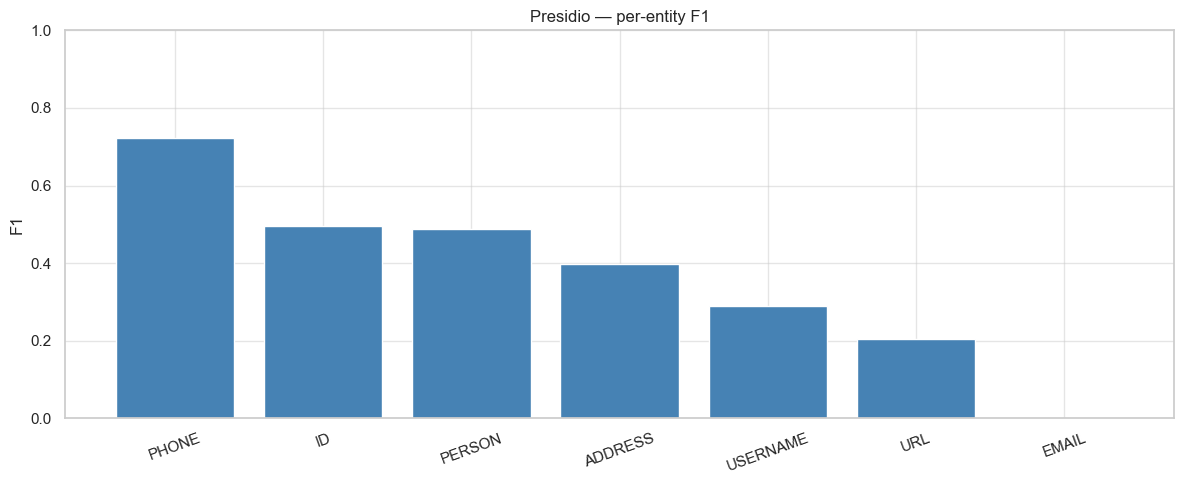

In [8]:
import pandas as pd
per = results['metrics'].get('per_entity', {})
rows = [{'entity': k, **v} for k, v in per.items()]
df = pd.DataFrame(rows).sort_values('f1', ascending=False)
display(df)

fig, ax = plt.subplots()
ax.bar(df['entity'], df['f1'], color='steelblue', edgecolor='white')
ax.set_title('Presidio — per-entity F1')
ax.set_ylim(0, 1)
ax.set_ylabel('F1')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('../outputs/results/presidio_per_entity_f1.png', dpi=150)
plt.show()

## 3. Qualitative sample – correct detections & misses

In [9]:
test_records = load_jsonl('../data/processed/test.jsonl')
preds = results['predictions']

print('=== Correct detections ===')
shown = 0
for rec, pred in zip(test_records, preds):
    true = rec['labels']
    hits = [(t, p) for t, p, tr in zip(rec['tokens'], pred, true) if p != 'O' and p == tr]
    if hits and shown < 3:
        print(' '.join(rec['tokens'][:20]), '...')
        print('  Detected:', hits[:5])
        shown += 1

print('\n=== Missed PII spans ===')
shown = 0
for rec, pred in zip(test_records, preds):
    true = rec['labels']
    misses = [(t, tr) for t, p, tr in zip(rec['tokens'], pred, true) if tr != 'O' and p == 'O']
    if misses and shown < 3:
        print(' '.join(rec['tokens'][:20]), '...')
        print('  Missed:', misses[:5])
        shown += 1

=== Correct detections ===
create a comparative analysis of the health care laws in massachusetts and massachusetts for jeffery kuhn , focusing on the ...
  Detected: [('massachusetts', 'B-ADDRESS'), ('massachusetts', 'B-ADDRESS'), ('jeffery', 'B-PERSON'), ('kuhn', 'I-PERSON')]
during our video conference , please provide spencer torp with an overview of cognitive - behavioral therapy for eating disorders ...
  Detected: [('spencer', 'B-PERSON'), ('torp', 'I-PERSON')]
explain the benefits of using analytics tools for tracking rhonda doyle ' s digital marketing campaign during our video conference ...
  Detected: [('rhonda', 'B-PERSON'), ('doyle', 'I-PERSON')]

=== Missed PII spans ===
my friend rodriguez llc is interested in mindfulness - based therapy . can you recommend a podcast or youtube channel ...
  Missed: [('rodriguez', 'B-PERSON'), ('llc', 'I-PERSON')]
draft a document for sonia schmeler outlining safety protocols for handling confidential information and preventing data leak